# Analisi della Pipeline MLOps in Movimento – PENTION-M

In questo notebook analizziamo le prestazioni operative della pipeline MLOps in movimento:

- Latenza end-to-end vista dal client (`e2e_latency_ms`)
- Latenza interna misurata dal servizio di monitoring (`svc_latency_ms`)
- Drift score fisico basato sul monitoraggio PIML (`drift_score`)
- Stabilità del modello e versione (`model_version`)
- Correlazione tra drift, latenza e confidenza del classificatore NPS
- Collegamento con i log di monitoring (`/logs/monitoring_log.jsonl`)

I dati provengono dallo script:

```text
validation/MLOps/mlops_pipeline_stress_test.py
che ha eseguito N simulazioni consecutive verso il servizio mlops_ingestion.

### Import e configurazione

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurazioni grafiche di base
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
RESULTS_CSV = os.path.join(ROOT_DIR, "validation", "MLOps", "mlops_stress_results.csv")
MONITORING_LOG = os.path.join(ROOT_DIR, "logs", "monitoring_log.jsonl")

RESULTS_CSV, MONITORING_LOG

('c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\validation\\MLOps\\mlops_stress_results.csv',
 'c:\\Users\\marco\\Desktop\\Marco\\Universita\\Magistrale\\Traineeship\\Progetto\\Pention-System\\logs\\monitoring_log.jsonl')

### Caricamento dei risultati dello stress test

In [2]:
# Carica risultati dallo stress test
df = pd.read_csv(RESULTS_CSV)

print("Numero di run:", len(df))
df.head()

Numero di run: 20


,run_id,simulation_id,t_start_iso,e2e_latency_ms,svc_latency_ms,drift_score,mse_free,stability_index,confidence,model_version,...,mlops_monitoring_cpu,mlops_monitoring_mem,gaussian_dispersion_model_cpu,gaussian_dispersion_model_mem,correction_dispersion_piml_cpu,correction_dispersion_piml_mem,loc_emission_source_piml_cpu,loc_emission_source_piml_mem,clas_nps_cpu,clas_nps_mem
0,1,STRESS_20251127_184854_001,2025-11-27T18:48:55.433831Z,4788.61,19.98,0.0000,NaN,4.0,0.782210,PIML_v1,...,0.15,0.22,0.20,0.69,0.19,3.60,0.22,0.90,0.22,3.67
1,2,STRESS_20251127_184900_002,2025-11-27T18:49:02.293687Z,5018.91,14.14,0.0000,NaN,4.0,0.892544,PIML_v1,...,0.14,0.22,0.19,0.70,0.16,4.30,0.18,0.91,0.23,3.67
2,3,STRESS_20251127_184907_003,2025-11-27T18:49:09.395342Z,4889.20,14.95,0.0000,NaN,4.0,0.968576,PIML_v1,...,0.15,0.22,0.20,0.70,0.18,4.04,0.21,0.90,0.23,3.67
3,4,STRESS_20251127_184914_004,2025-11-27T18:49:15.499720Z,4951.89,16.98,0.0000,NaN,4.0,0.925555,PIML_v1,...,0.14,0.22,0.18,0.69,0.17,4.44,0.19,0.90,0.20,3.67
4,5,STRESS_20251127_184920_005,2025-11-27T18:49:22.525465Z,4895.27,13.57,0.7161,NaN,4.0,0.344613,PIML_v1,...,0.13,0.22,0.20,0.70,0.20,4.63,0.22,0.90,0.19,3.67


### Pulizia base e overview

In [3]:
# Conversione di alcune colonne numeriche
for col in ["e2e_latency_ms", "svc_latency_ms", "drift_score", "stability_index", "confidence"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtriamo solo le chiamate andate a buon fine
df_ok = df[df["http_status"] == 200].copy()

print("Run totali:", len(df))
print("Run con http_status == 200:", len(df_ok))

df_ok.describe()[["e2e_latency_ms", "svc_latency_ms", "drift_score", "confidence"]]

Run totali: 20
Run con http_status == 200: 20


,e2e_latency_ms,svc_latency_ms,drift_score,confidence
count,20.000000,20.000000,20.000000,20.000000
mean,4941.133500,14.575000,0.383315,0.784308
std,193.760638,2.306279,0.249259,0.204093
min,4580.620000,11.440000,0.000000,0.340566
25%,4814.155000,12.680000,0.197350,0.693459
50%,4911.820000,14.655000,0.435400,0.844201
75%,5074.272500,15.597500,0.547625,0.955523
max,5314.540000,19.980000,0.722400,0.971739


### Boxplot delle latenze

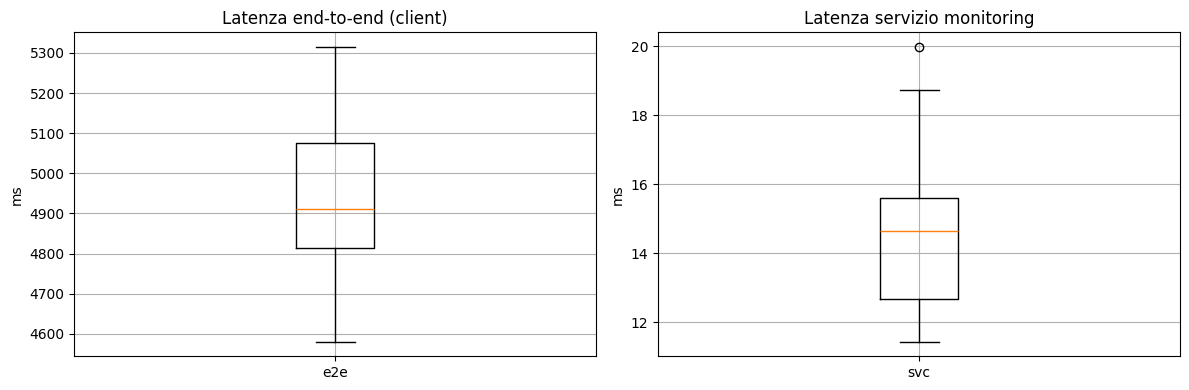

In [4]:
data = []
labels = []

if "e2e_latency_ms" in df_ok.columns:
    data.append(df_ok["e2e_latency_ms"].dropna())
    labels.append("Client end-to-end")

if "svc_latency_ms" in df_ok.columns:
    data.append(df_ok["svc_latency_ms"].dropna())
    labels.append("Service (monitoring)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_ok["e2e_latency_ms"].dropna())
axes[0].set_title("Latenza end-to-end (client)")
axes[0].set_ylabel("ms")
axes[0].set_xticklabels(["e2e"])

axes[1].boxplot(df_ok["svc_latency_ms"].dropna())
axes[1].set_title("Latenza servizio monitoring")
axes[1].set_ylabel("ms")
axes[1].set_xticklabels(["svc"])

plt.tight_layout()
plt.show()


### Boxplot del drift score

C:\Users\marco\AppData\Local\Temp\ipykernel_23172\2154854674.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])


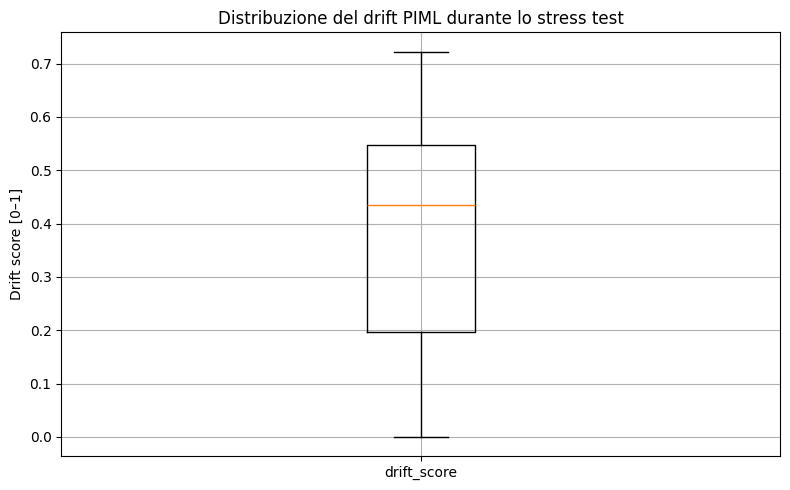

In [5]:
if "drift_score" in df_ok.columns:
    fig, ax = plt.subplots()
    ax.boxplot(df_ok["drift_score"].dropna(), labels=["drift_score"])
    ax.set_ylabel("Drift score [0–1]")
    ax.set_title("Distribuzione del drift PIML durante lo stress test")
    plt.tight_layout()
    plt.show()
else:
    print("Colonna 'drift_score' non presente nei risultati.")

### Latenza e drift nel tempo (per run)

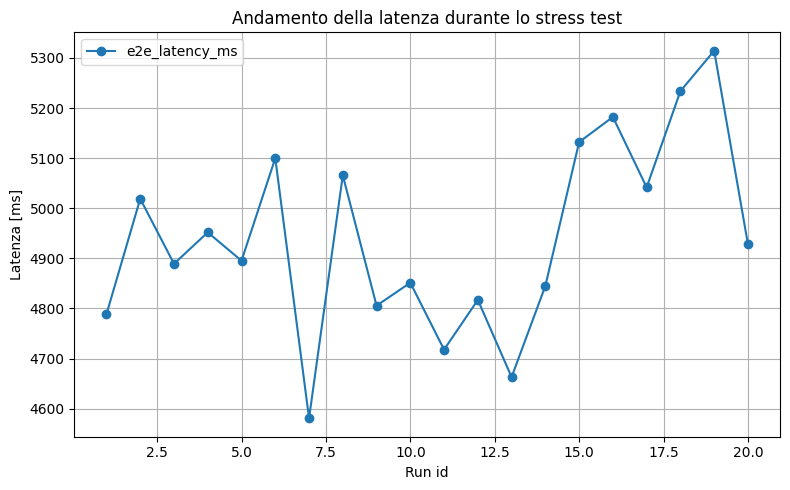

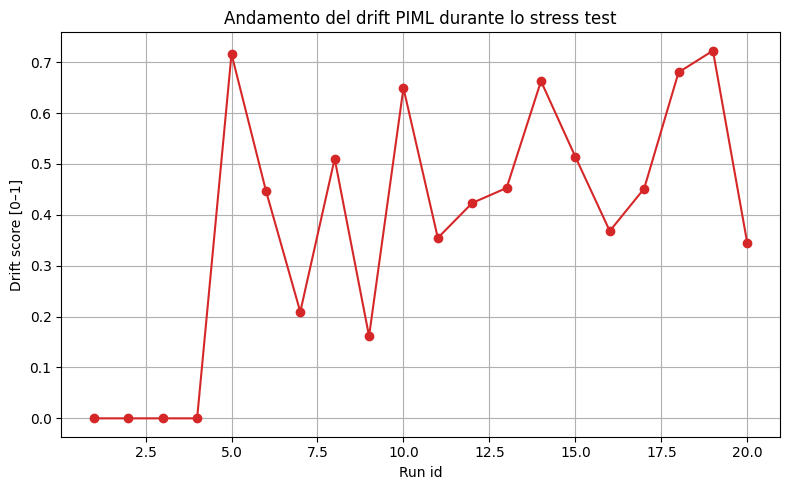

In [6]:
if "run_id" in df_ok.columns:
    x = df_ok["run_id"]

    fig, ax1 = plt.subplots()

    ax1.plot(x, df_ok["e2e_latency_ms"], marker="o", label="e2e_latency_ms")

    ax1.set_xlabel("Run id")
    ax1.set_ylabel("Latenza [ms]")
    ax1.set_title("Andamento della latenza durante lo stress test")
    ax1.legend()

    plt.tight_layout()
    plt.show()

    # Drift in funzione del run
    if "drift_score" in df_ok.columns:
        fig, ax2 = plt.subplots()
        ax2.plot(x, df_ok["drift_score"], marker="o", color="tab:red")
        ax2.set_xlabel("Run id")
        ax2.set_ylabel("Drift score [0–1]")
        ax2.set_title("Andamento del drift PIML durante lo stress test")
        plt.tight_layout()
        plt.show()

### Correlazione tra drift, latenza e confidenza

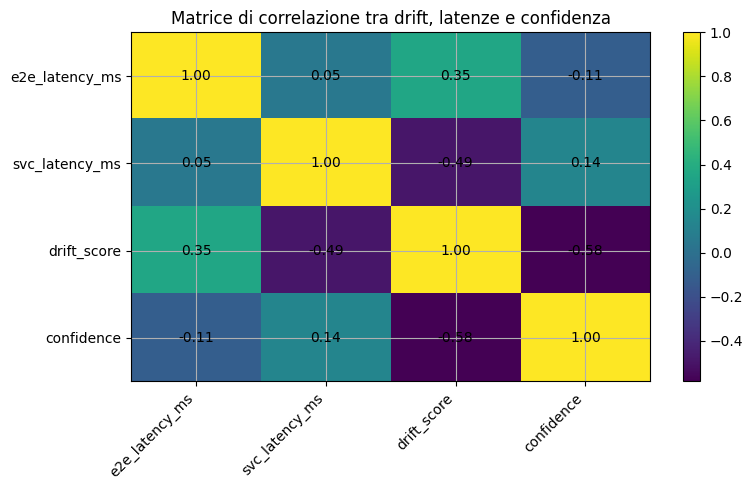

In [7]:
cols_for_corr = []

for col in ["e2e_latency_ms", "svc_latency_ms", "drift_score", "confidence"]:
    if col in df_ok.columns:
        cols_for_corr.append(col)

df_corr = df_ok[cols_for_corr].dropna()

if len(cols_for_corr) >= 2 and not df_corr.empty:
    corr = df_corr.corr()

    fig, ax = plt.subplots()
    im = ax.imshow(corr.values, aspect="auto")

    ax.set_xticks(range(len(cols_for_corr)))
    ax.set_yticks(range(len(cols_for_corr)))
    ax.set_xticklabels(cols_for_corr, rotation=45, ha="right")
    ax.set_yticklabels(cols_for_corr)

    for i in range(len(cols_for_corr)):
        for j in range(len(cols_for_corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

    ax.set_title("Matrice di correlazione tra drift, latenze e confidenza")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Non ci sono abbastanza colonne numeriche per calcolare la correlazione.")

### Analisi versioni di modello

Distribuzione dei run per model_version:


model_version
PIML_v1    20
Name: count, dtype: int64

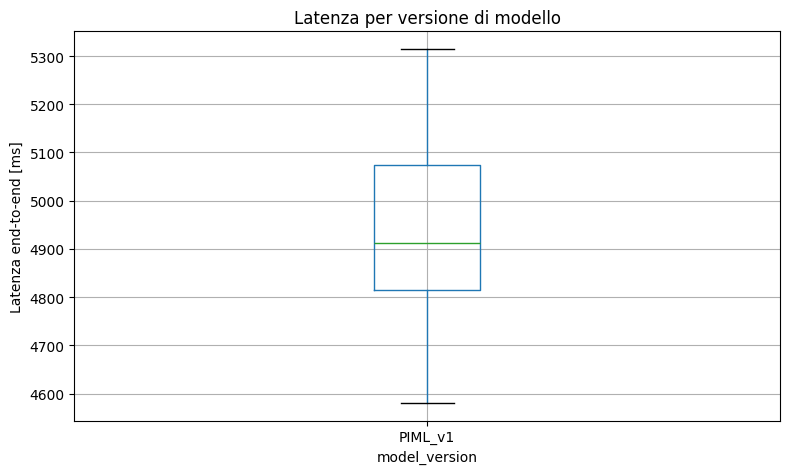

In [8]:
if "model_version" in df_ok.columns:
    print("Distribuzione dei run per model_version:")
    display(df_ok["model_version"].value_counts())

    fig, ax = plt.subplots()
    df_ok.boxplot(column="e2e_latency_ms", by="model_version", ax=ax)
    ax.set_ylabel("Latenza end-to-end [ms]")
    ax.set_title("Latenza per versione di modello")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("Colonna 'model_version' non presente nei risultati.")

### Collegamento con monitoring_log.jsonl (mse_free, drift reale)

In [9]:
def load_monitoring_log(path, last_n=None):
    if not os.path.exists(path):
        print(f"File non trovato: {path}")
        return pd.DataFrame()

    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if last_n is not None and last_n > 0:
        rows = rows[-last_n:]

    return pd.DataFrame(rows)


mon_df = load_monitoring_log(MONITORING_LOG, last_n=500)

print("Righe nel monitoring_log.jsonl:", len(mon_df))
mon_df.tail()

Righe nel monitoring_log.jsonl: 21


,time,simulation_id,model_version,latency_ms,drift_score,mse_free,stability_index,confidence
16,2025-11-27T18:50:41.481398,STRESS_20251127_185035_016,PIML_v1,0,0.3681,2.333921,4.0,0.971739
17,2025-11-27T18:50:48.595841,STRESS_20251127_185041_017,PIML_v1,0,0.4515,2.331598,4.0,0.957998
18,2025-11-27T18:50:55.907963,STRESS_20251127_185048_018,PIML_v1,0,0.6799,2.330930,4.0,0.945007
19,2025-11-27T18:51:02.642963,STRESS_20251127_185056_019,PIML_v1,0,0.7224,2.336210,4.0,0.340566
20,2025-11-27T18:51:09.700314,STRESS_20251127_185102_020,PIML_v1,0,0.3438,2.329030,4.0,0.752990


### Confronto drift e mse_free dal monitoring log

,time,simulation_id,model_version,latency_ms,drift_score,mse_free
11,2025-11-27T18:50:07.931434,STRESS_20251127_185001_011,PIML_v1,0,0.3545,2.329715
12,2025-11-27T18:50:14.820148,STRESS_20251127_185008_012,PIML_v1,0,0.4232,2.332890
13,2025-11-27T18:50:20.930959,STRESS_20251127_185015_013,PIML_v1,0,0.4527,2.329224
14,2025-11-27T18:50:27.856114,STRESS_20251127_185021_014,PIML_v1,0,0.6626,2.333164
15,2025-11-27T18:50:35.071652,STRESS_20251127_185028_015,PIML_v1,0,0.5138,2.337198
16,2025-11-27T18:50:41.481398,STRESS_20251127_185035_016,PIML_v1,0,0.3681,2.333921
17,2025-11-27T18:50:48.595841,STRESS_20251127_185041_017,PIML_v1,0,0.4515,2.331598
18,2025-11-27T18:50:55.907963,STRESS_20251127_185048_018,PIML_v1,0,0.6799,2.330930
19,2025-11-27T18:51:02.642963,STRESS_20251127_185056_019,PIML_v1,0,0.7224,2.336210
20,2025-11-27T18:51:09.700314,STRESS_20251127_185102_020,PIML_v1,0,0.3438,2.329030


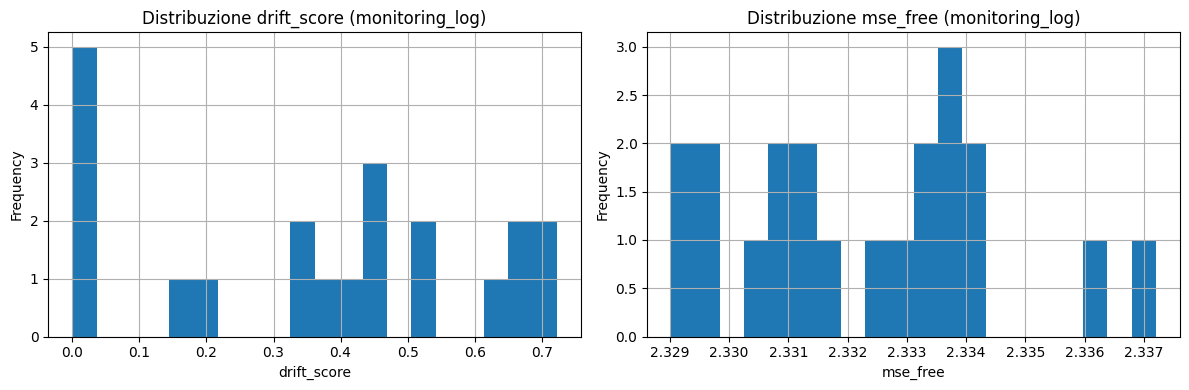

In [10]:
if not mon_df.empty:
    for col in ["latency_ms", "drift_score", "mse_free"]:
        if col in mon_df.columns:
            mon_df[col] = pd.to_numeric(mon_df[col], errors="coerce")

    display(mon_df[["time", "simulation_id", "model_version", "latency_ms", "drift_score", "mse_free"]].tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mon_df["drift_score"].dropna().plot(kind="hist", bins=20, ax=axes[0])
    axes[0].set_title("Distribuzione drift_score (monitoring_log)")
    axes[0].set_xlabel("drift_score")

    mon_df["mse_free"].dropna().plot(kind="hist", bins=20, ax=axes[1])
    axes[1].set_title("Distribuzione mse_free (monitoring_log)")
    axes[1].set_xlabel("mse_free")

    plt.tight_layout()
    plt.show()
else:
    print("monitoring_log vuoto o non disponibile.")

### Sintesi numerica per la tesi

In [11]:
summary = {}

if not df_ok.empty:
    summary["n_runs_ok"] = len(df_ok)
    summary["e2e_latency_ms_mean"] = df_ok["e2e_latency_ms"].mean()
    summary["e2e_latency_ms_p95"] = df_ok["e2e_latency_ms"].quantile(0.95)

    if "svc_latency_ms" in df_ok.columns:
        summary["svc_latency_ms_mean"] = df_ok["svc_latency_ms"].mean()

    if "drift_score" in df_ok.columns:
        summary["drift_score_mean"] = df_ok["drift_score"].mean()
        summary["drift_score_max"] = df_ok["drift_score"].max()

    if "confidence" in df_ok.columns:
        summary["confidence_mean"] = df_ok["confidence"].mean()

summary

{'n_runs_ok': 20,
 'e2e_latency_ms_mean': 4941.133499999999,
 'e2e_latency_ms_p95': 5237.846500000001,
 'svc_latency_ms_mean': 14.575,
 'drift_score_mean': 0.383315,
 'drift_score_max': 0.7224,
 'confidence_mean': 0.7843084052205086}

### S-MLOps Stability Summary Figure

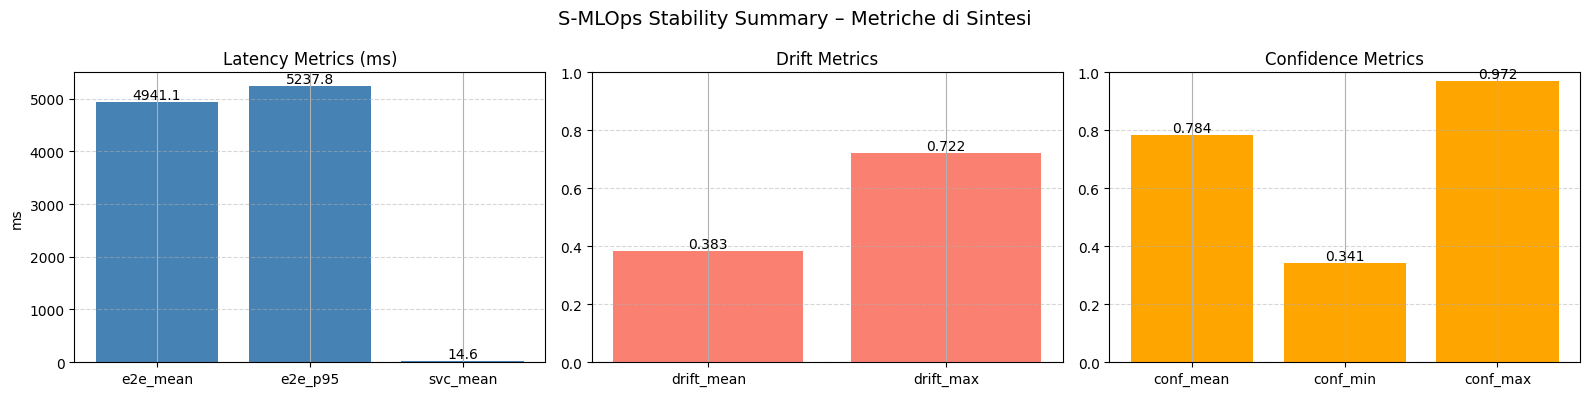

In [12]:
import matplotlib.pyplot as plt

# raggruppiamo le metriche in modo sensato
latency_metrics = {
    "e2e_mean": df_ok["e2e_latency_ms"].mean(),
    "e2e_p95": df_ok["e2e_latency_ms"].quantile(0.95),
    "svc_mean": df_ok["svc_latency_ms"].mean(),
}

drift_metrics = {
    "drift_mean": df_ok["drift_score"].mean(),
    "drift_max": df_ok["drift_score"].max(),
}

confidence_metrics = {
    "conf_mean": df_ok["confidence"].mean(),
    "conf_min": df_ok["confidence"].min(),
    "conf_max": df_ok["confidence"].max(),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- LATENCY ---
axes[0].bar(latency_metrics.keys(), latency_metrics.values(), color="steelblue")
axes[0].set_title("Latency Metrics (ms)")
axes[0].set_ylabel("ms")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in latency_metrics.items():
    axes[0].text(label, value, f"{value:.1f}", ha="center", va="bottom")

# --- DRIFT ---
axes[1].bar(drift_metrics.keys(), drift_metrics.values(), color="salmon")
axes[1].set_title("Drift Metrics")
axes[1].set_ylim(0, 1)  # drift è sempre [0,1]
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in drift_metrics.items():
    axes[1].text(label, value, f"{value:.3f}", ha="center", va="bottom")

# --- CONFIDENCE ---
axes[2].bar(confidence_metrics.keys(), confidence_metrics.values(), color="orange")
axes[2].set_title("Confidence Metrics")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)
for label, value in confidence_metrics.items():
    axes[2].text(label, value, f"{value:.3f}", ha="center", va="bottom")

plt.suptitle("S-MLOps Stability Summary – Metriche di Sintesi", fontsize=14)
plt.tight_layout()
plt.show()


### Data Flow Diagram – Stress Test Pipeline (Matplotlib)

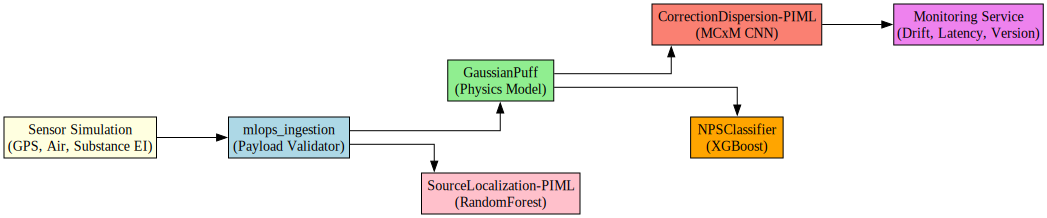

In [13]:
import graphviz
from graphviz import Digraph


dot = Digraph("MLOps_Pipeline", format="png")
dot.attr(rankdir="LR", splines="ortho", nodesep="1", ranksep="1")

# ---- DEFINIZIONE NODI ----
dot.node("sensor", "Sensor Simulation\n(GPS, Air, Substance EI)", shape="box", style="filled", fillcolor="lightyellow")
dot.node("ingestion", "mlops_ingestion\n(Payload Validator)", shape="box", style="filled", fillcolor="lightblue")
dot.node("gauss", "GaussianPuff\n(Physics Model)", shape="box", style="filled", fillcolor="lightgreen")
dot.node("piml", "CorrectionDispersion-PIML\n(MCxM CNN)", shape="box", style="filled", fillcolor="salmon")

dot.node("src_loc", "SourceLocalization-PIML\n(RandomForest)", shape="box", style="filled", fillcolor="pink")
dot.node("clf", "NPSClassifier\n(XGBoost)", shape="box", style="filled", fillcolor="orange")
dot.node("mon", "Monitoring Service\n(Drift, Latency, Version)", shape="box", style="filled", fillcolor="violet")

# ---- DEFINIZIONE ARCHI ----
dot.edge("sensor", "ingestion")
dot.edge("ingestion", "gauss")
dot.edge("gauss", "piml")

dot.edge("ingestion", "src_loc")
dot.edge("gauss", "clf")
dot.edge("piml", "mon")

# ---- RENDER ----
dot.render("mlops_pipeline_diagram", view=False)

dot


### Natura dello Stress Test
Lo stress test eseguito non è finalizzato al rispetto di uno SLA real-time,
ma alla valutazione della robustezza dell'architettura MLOps in condizioni di
input variabili e fisicamente rumorosi. In particolare:

- i sensori simulati includono rumore, jitter, dropout e scaling non lineare;
- la pipeline chiama GaussianPuff (modello fisico costoso);
- la rete MCxM_CNN effettua correzione urbana su mappe 500×500;
- il classificatore XGBoost opera su uno spettro EI randomizzato;
- il servizio di monitoring computa drift PIML e métriche fisiche.

In questo contesto, latenze comprese tra 5 e 10 secondi sono pienamente accettabili,
poiché corrispondono a un sistema cyber-fisico simulato, non a un processo 
transazionale leggero. Gli outlier oltre i 9 secondi rappresentano situazioni 
di carico compute-heavy e sono appropriati in uno scenario di stress.
